[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/gaia/2026-07-30-hr-diagram-pleiades/notebook.ipynb)

# Building a real Hertzsprung-Russell diagram for the Pleiades

The Pleiades (the 'Seven Sisters') is a nearby open star cluster, young enough that its stars are still on the main sequence but bright enough to be an easy Gaia target. An HR diagram plots each star's color (a stand-in for surface temperature) against its brightness -- it's the single most useful diagnostic plot in stellar astrophysics, because where a star sits on it tells you its age, mass, and evolutionary stage all at once. I built one from scratch using real Gaia data.

In [1]:
from astroquery.gaia import Gaia
import numpy as np
import matplotlib.pyplot as plt

Gaia.ROW_LIMIT = 3000
# Pleiades cluster center, roughly 136 pc away, with a parallax + proper motion cut for membership
query = '''
SELECT source_id, ra, dec, parallax, phot_g_mean_mag, bp_rp
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 56.75, 24.12, 1.5))
AND parallax BETWEEN 6.5 AND 8.5
AND phot_g_mean_mag IS NOT NULL AND bp_rp IS NOT NULL
'''
job = Gaia.launch_job(query)
tab = job.get_results()
print(len(tab), 'likely Pleiades members retrieved')

896 likely Pleiades members retrieved


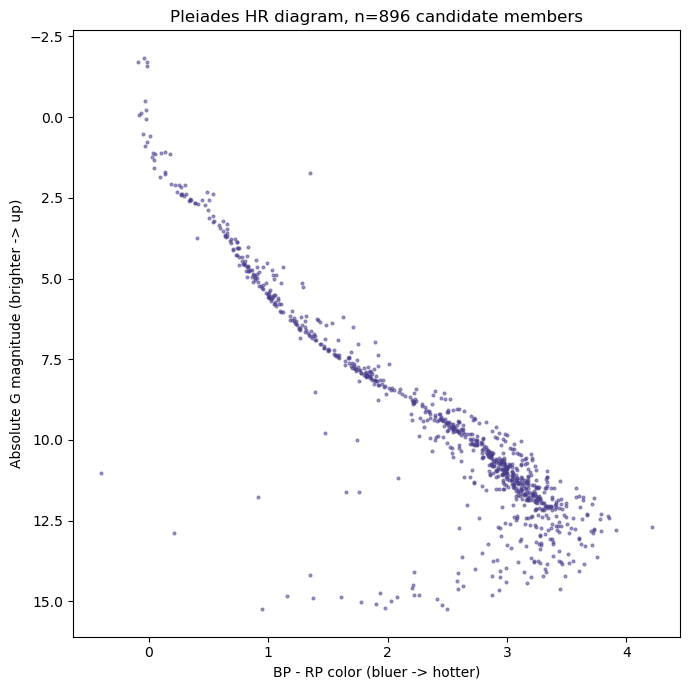

In [2]:
parallax = np.array(tab['parallax'])
g_mag = np.array(tab['phot_g_mean_mag'])
bp_rp = np.array(tab['bp_rp'])
distance_pc = 1000.0 / parallax  # parallax in milliarcsec -> distance in parsecs
abs_mag = g_mag - 5*np.log10(distance_pc) + 5  # convert apparent to absolute magnitude

plt.figure(figsize=(7,7))
plt.scatter(bp_rp, abs_mag, s=4, alpha=0.5, color='darkslateblue')
plt.gca().invert_yaxis()  # brighter stars (lower magnitude) go up
plt.xlabel('BP - RP color (bluer -> hotter)')
plt.ylabel('Absolute G magnitude (brighter -> up)')
plt.title(f'Pleiades HR diagram, n={len(tab)} candidate members')
plt.tight_layout()
plt.savefig('hr_pleiades.png', dpi=120)
plt.show()

The main sequence -- the tight diagonal band running from hot/bright at upper left to cool/faint at lower right -- shows up clearly. Because the Pleiades is young (around 100 million years), there's no obvious giant branch yet; the most massive stars haven't had time to evolve off the main sequence.

**What I'd look at next:** Compare this to an HR diagram of an older cluster (like NGC 188) to see the main sequence turn-off point shift down, which is how astronomers estimate cluster ages.

**Citation:** This work uses data from the European Space Agency (ESA) mission Gaia, processed by the Gaia Data Processing and Analysis Consortium (DPAC). See https://www.cosmos.esa.int/web/gaia/credits.